# set up

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


# import data

In [2]:
dataset=pd.read_csv(r'C:\Users\beher\OneDrive\Desktop\DeepLearning\Time Series\AirPassengers.csv')

In [3]:
dataset.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
dataset.columns=['Date','Number of Passengers']
dataset.head()

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Visualize the time series

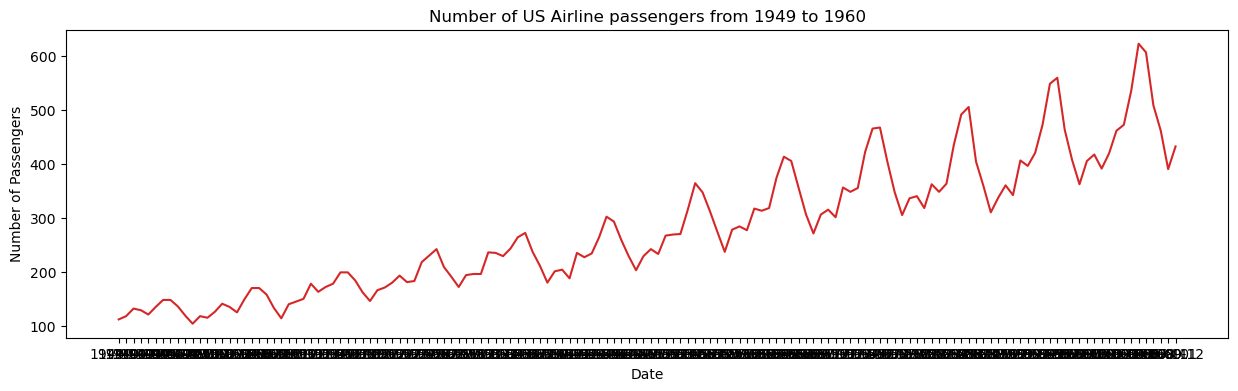

In [6]:
def plot_df(df,x,y,title='',xlabel='Date',ylabel='Number of Passengers',dpi=100):
    plt.figure(figsize=(15,4),dpi=dpi)
    plt.plot(x,y,color='tab:red')
    plt.gca().set(title=title,xlabel=xlabel,ylabel=ylabel)
    plt.show()



plot_df(dataset, x=dataset['Date'], y=dataset['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')


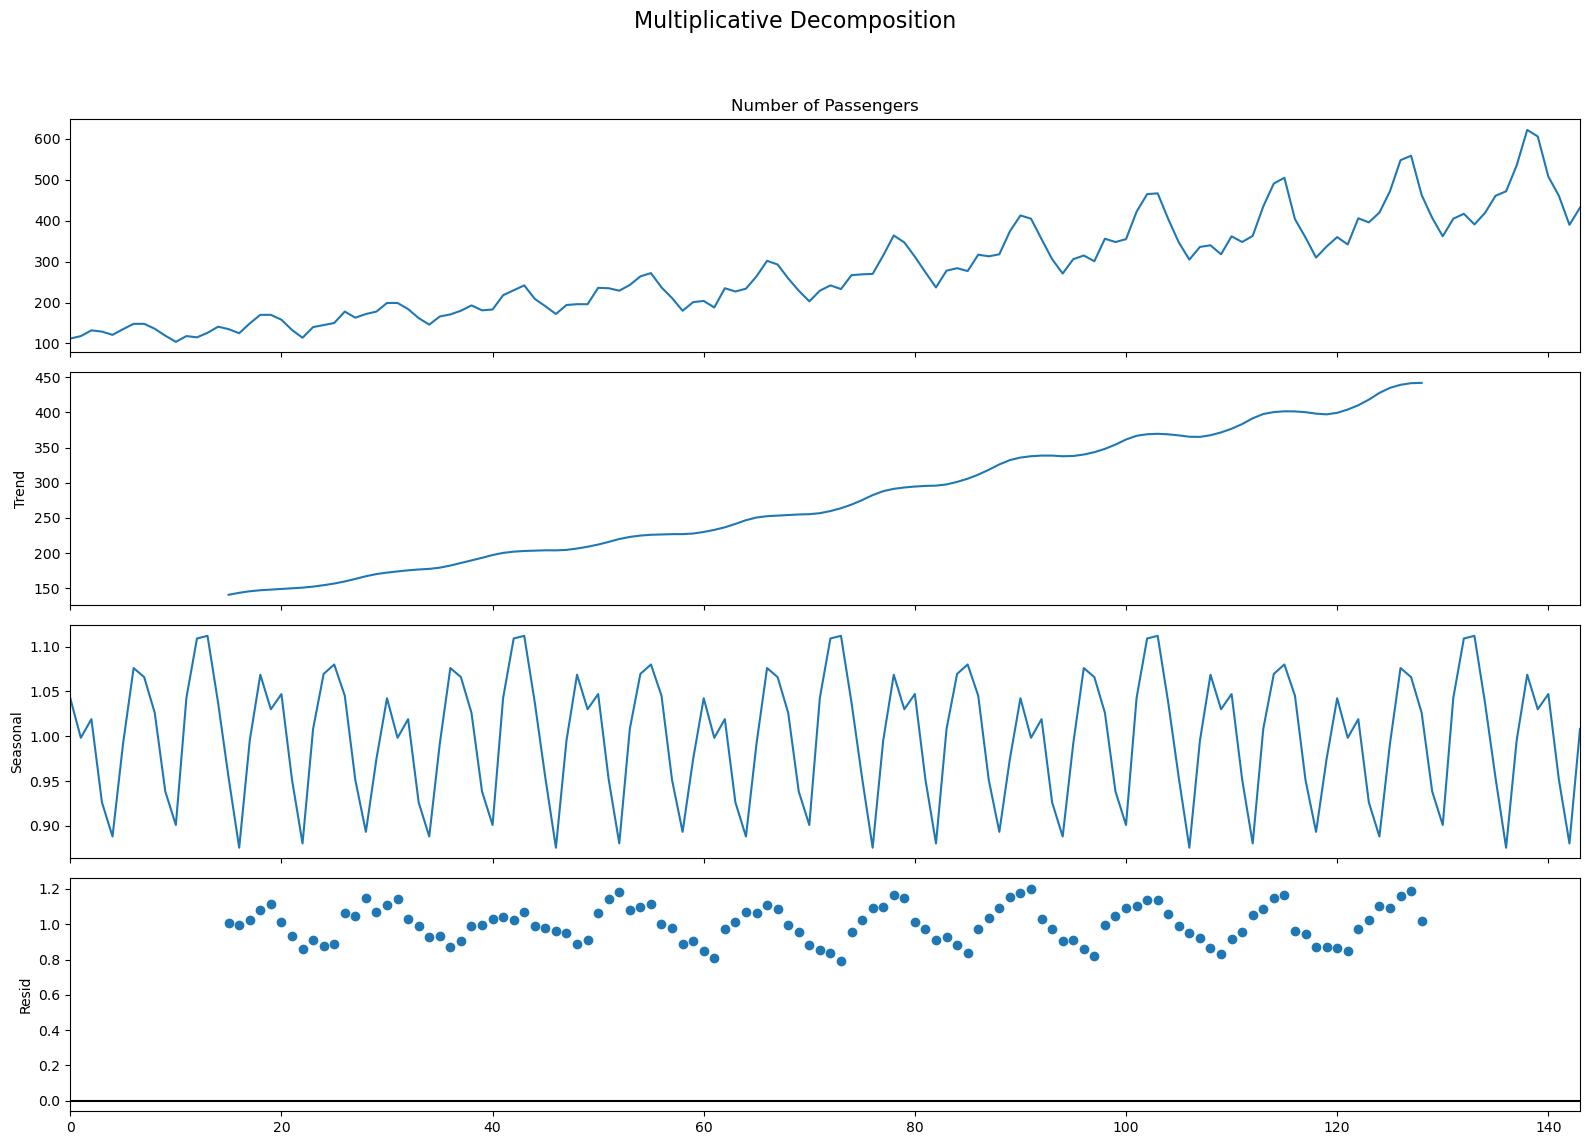

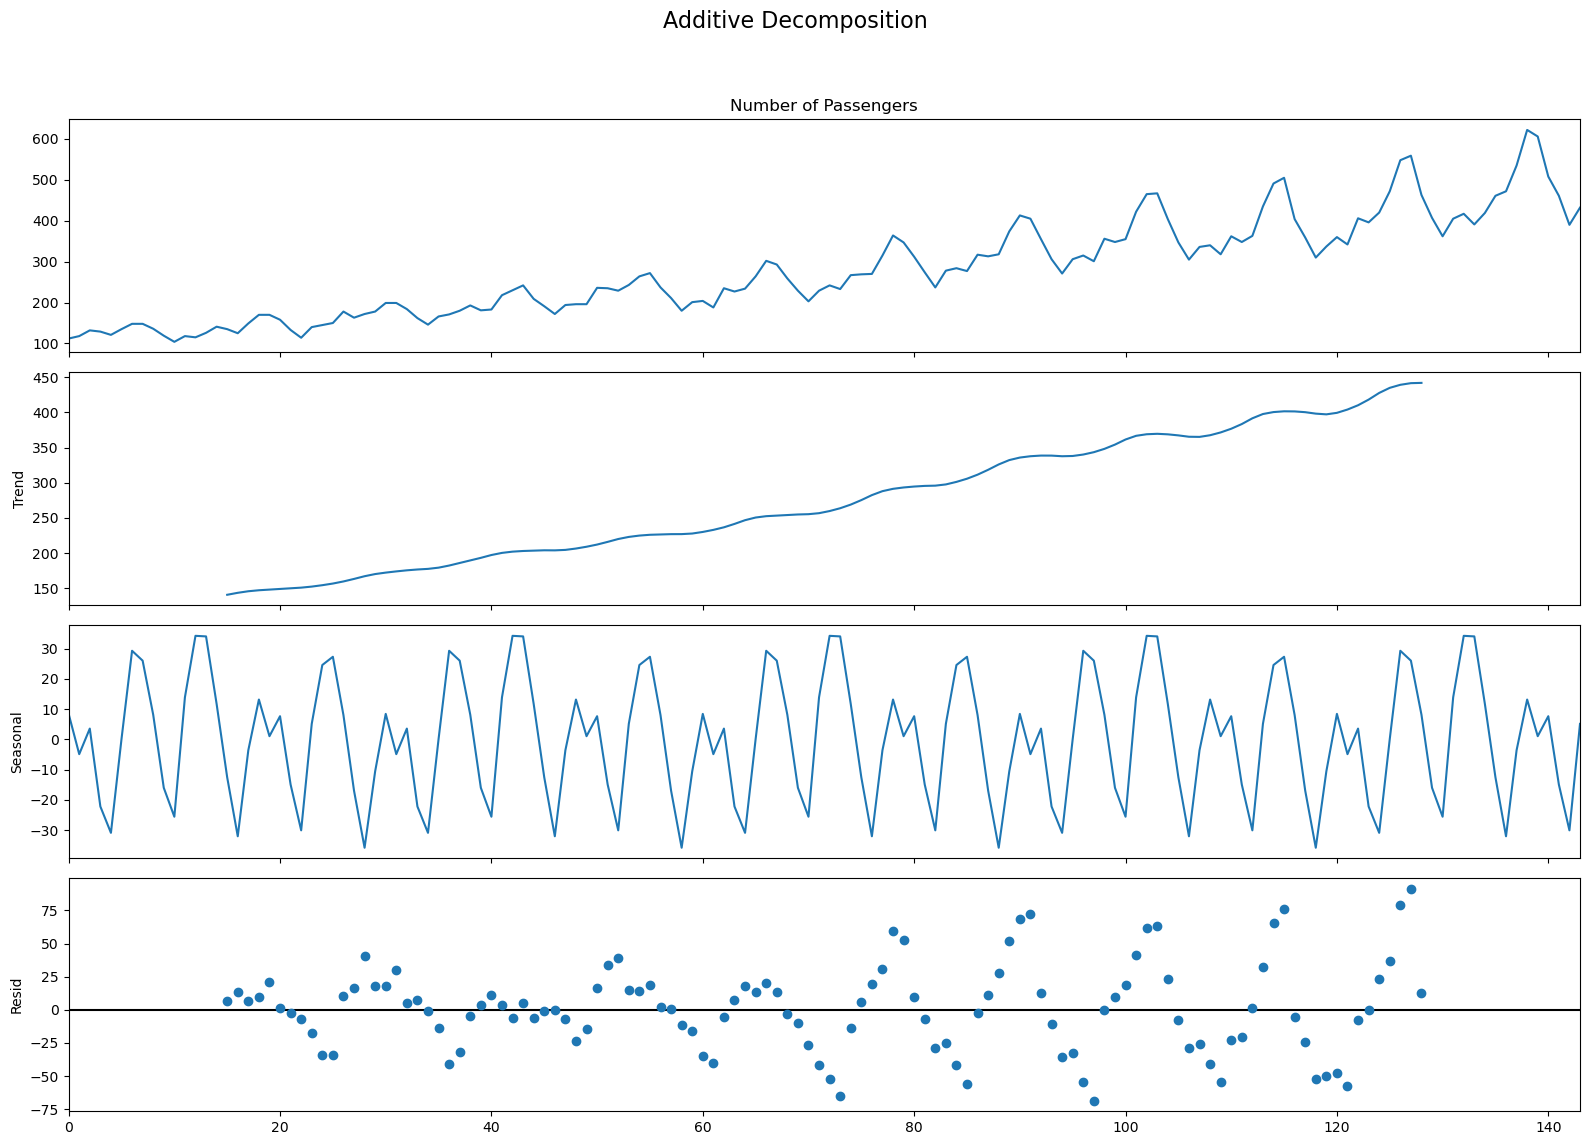

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse



multiplicative_decomposition = seasonal_decompose(dataset['Number of Passengers'], model='multiplicative', period=30)


additive_decomposition = seasonal_decompose(dataset['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


# Difference Between white noise and a stationary series

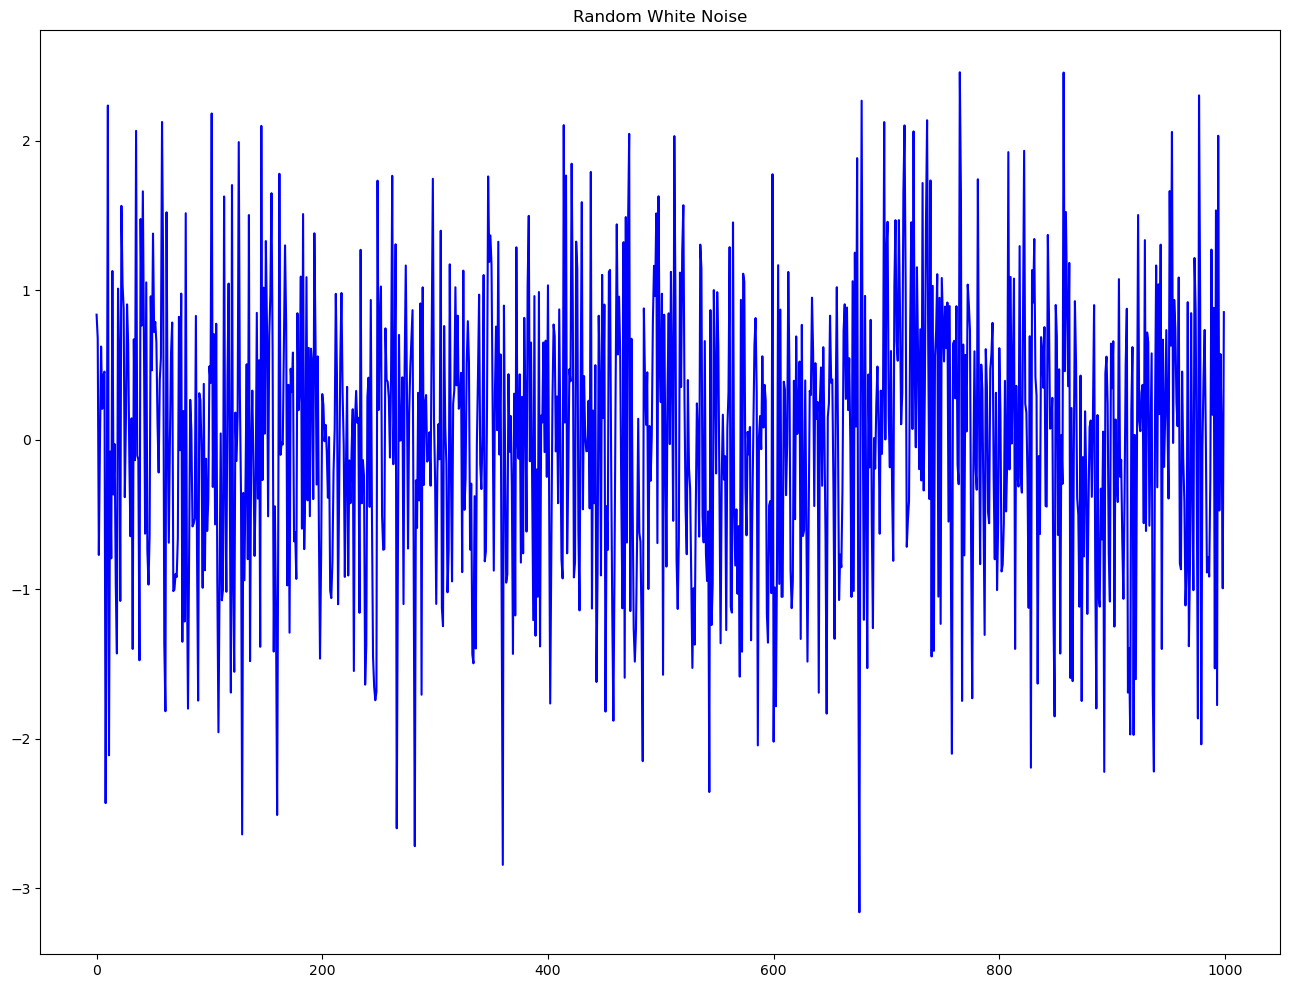

In [9]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')
plt.show()

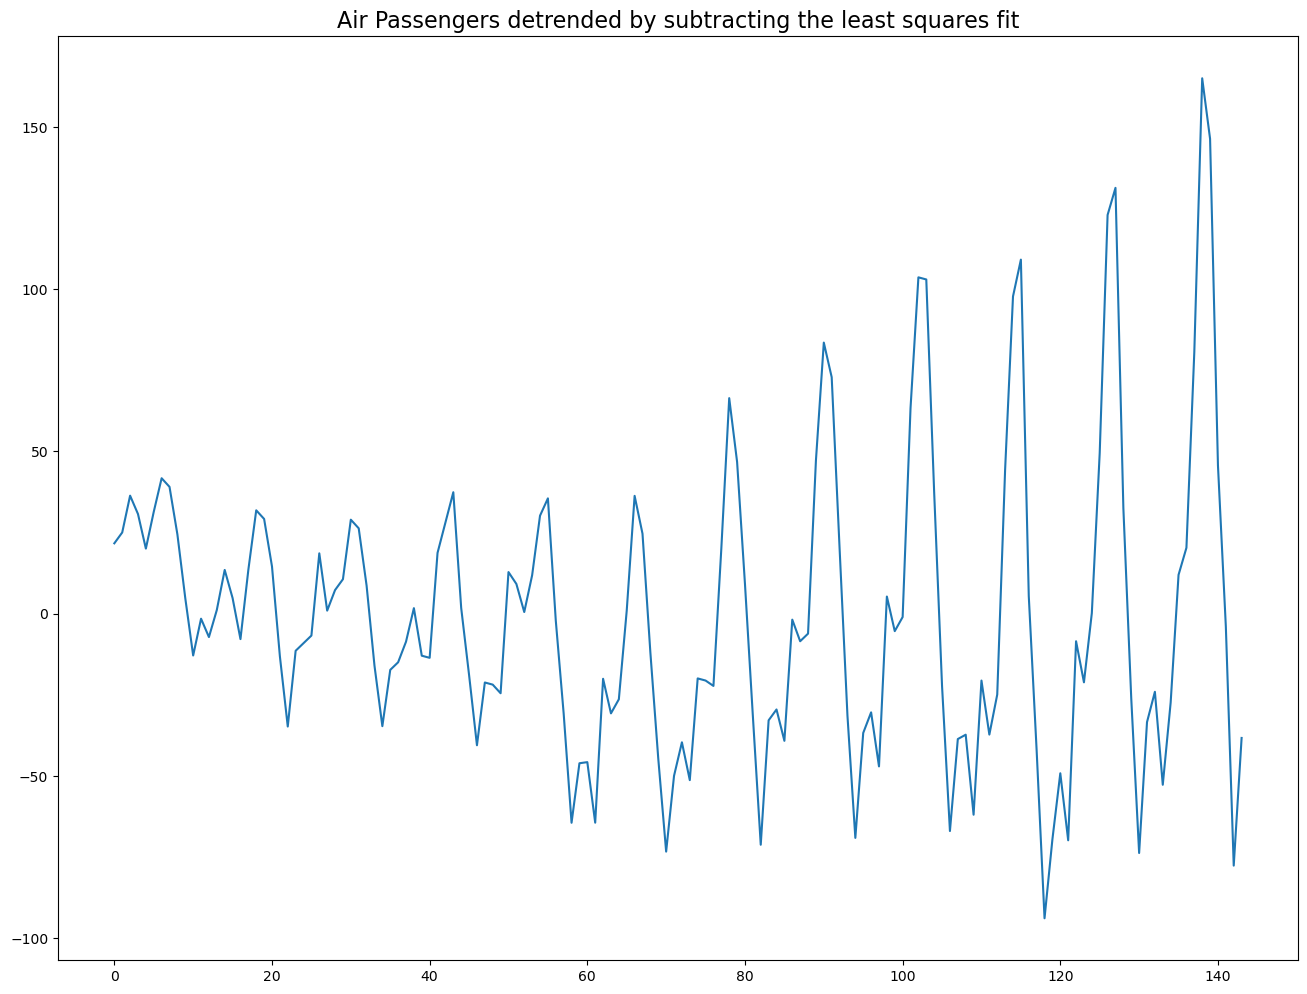

In [11]:
from scipy import signal
detrended = signal.detrend(dataset['Number of Passengers'].values)
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=16)
plt.show()

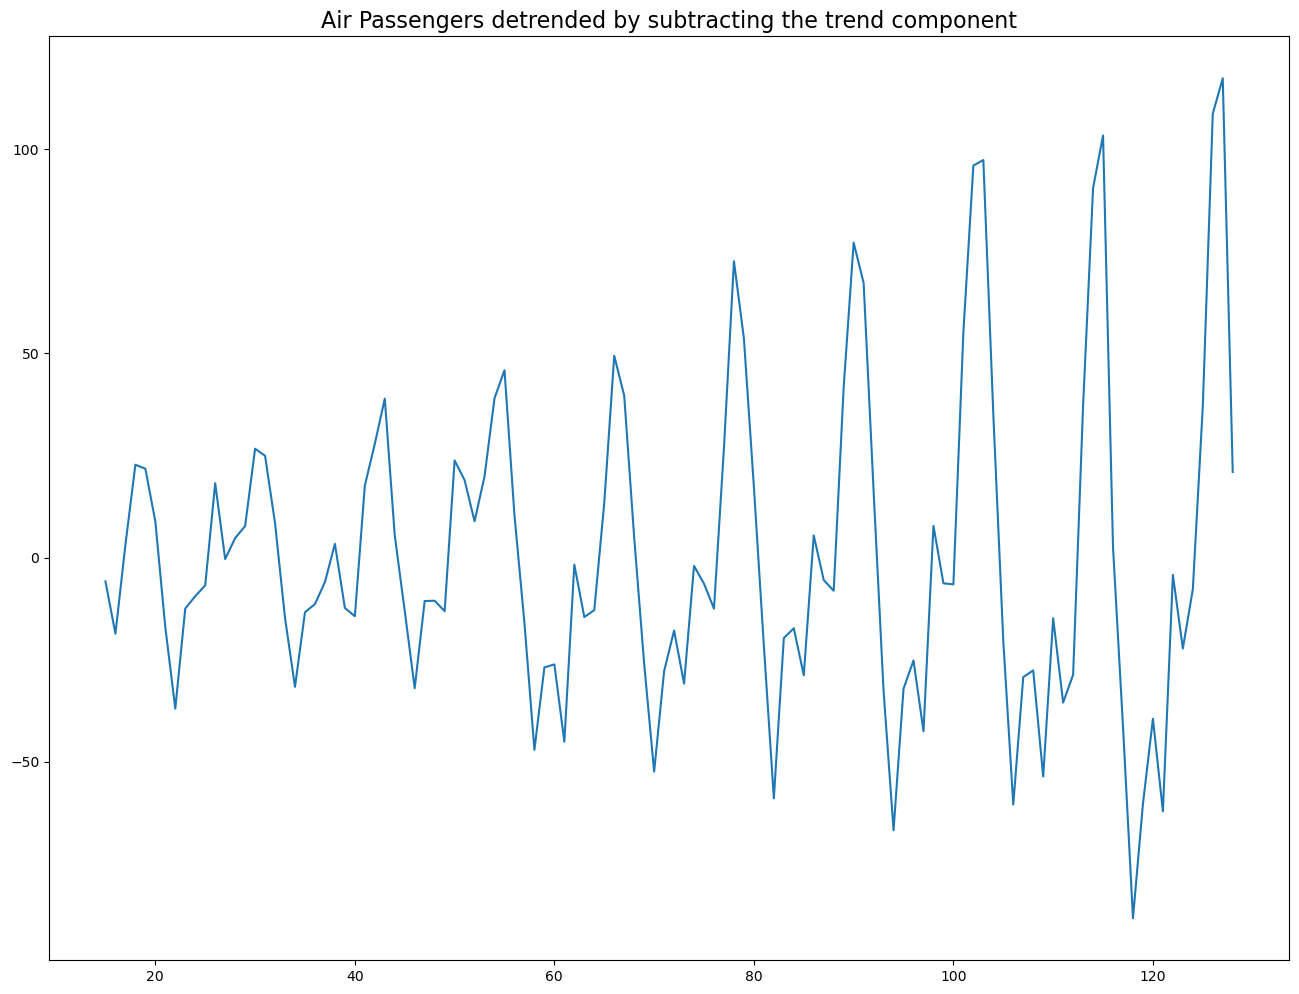

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(dataset['Number of Passengers'], model='multiplicative', period=30)
detrended = dataset['Number of Passengers'].values - result_mul.trend
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=16)
plt.show()

[]

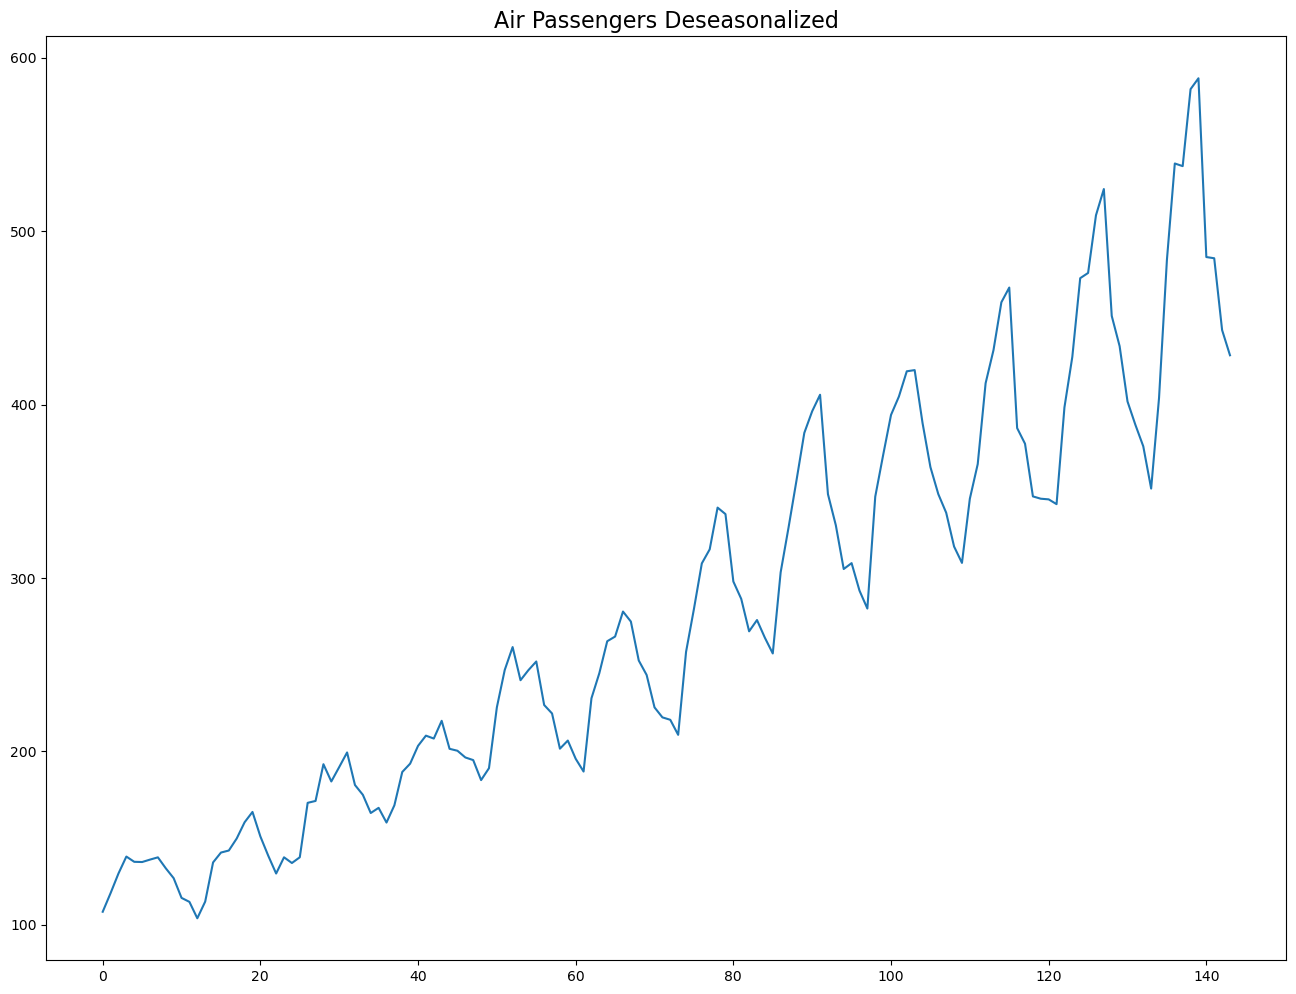

In [13]:
result_mul = seasonal_decompose(dataset['Number of Passengers'], model='multiplicative', period=30)


# Deseasonalize
deseasonalized = dataset['Number of Passengers'].values / result_mul.seasonal


# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot()

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

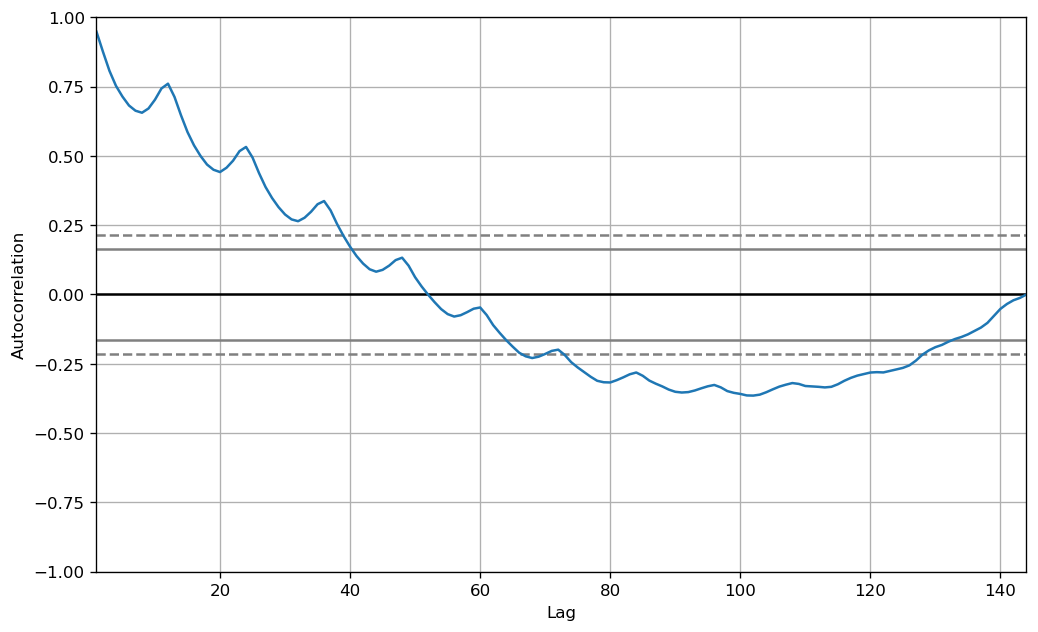

In [14]:
from pandas.plotting import autocorrelation_plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(dataset['Number of Passengers'].tolist())

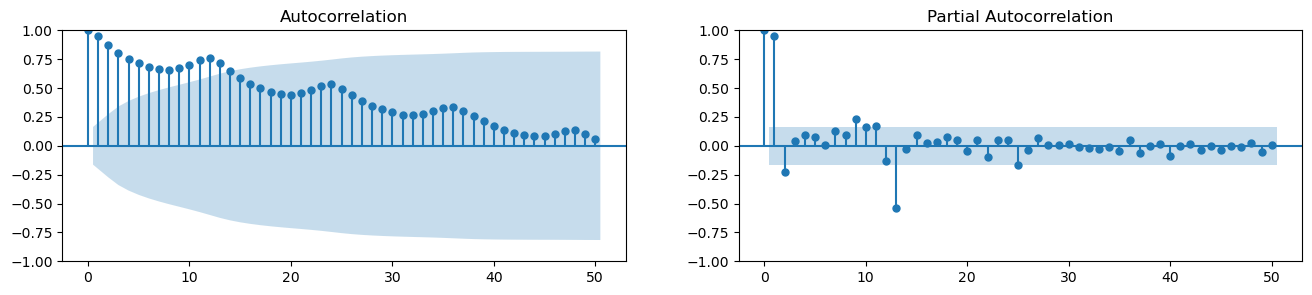

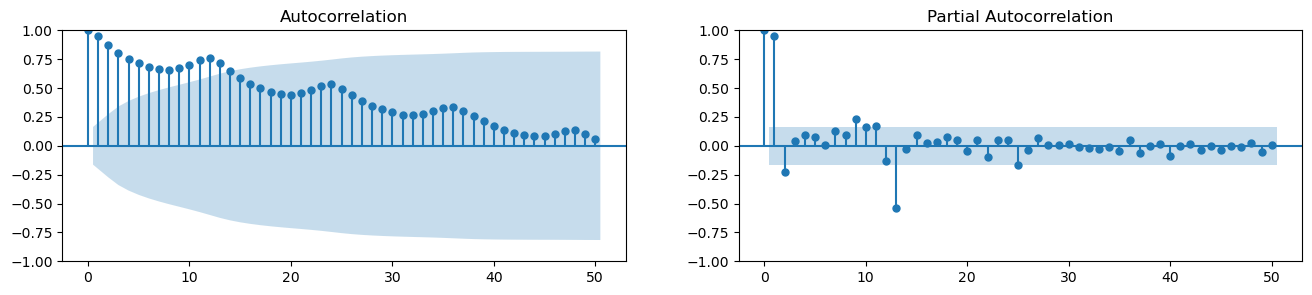

In [16]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(dataset['Number of Passengers'].tolist(), lags=50, ax=axes[0])
plot_pacf(dataset['Number of Passengers'].tolist(), lags=50, ax=axes[1])

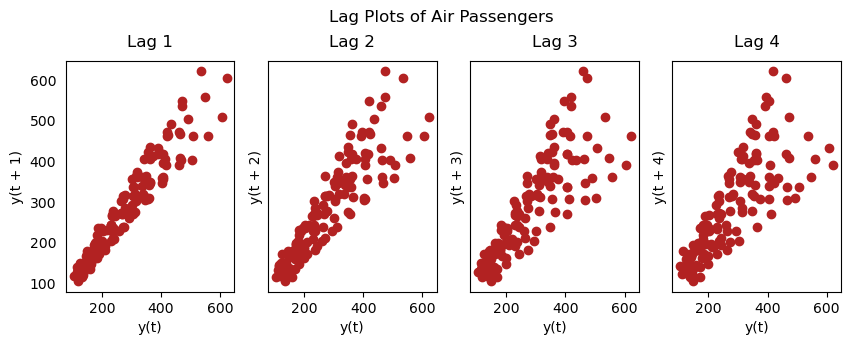

In [17]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(dataset['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)    
plt.show()

In [19]:
from statsmodels.tsa.stattools import grangercausalitytests
data = pd.read_csv(r"C:\Users\beher\OneDrive\Desktop\DeepLearning\Time Series\dataset.txt")
data['date'] = pd.to_datetime(data['date'])
data['month'] = data.date.dt.month
grangercausalitytests(data[['value', 'month']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1
ssr based chi2 test:   chi2=55.6014 , p=0.0000  , df=1
likelihood ratio test: chi2=49.1426 , p=0.0000  , df=1
parameter F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2
ssr based chi2 test:   chi2=333.6567, p=0.0000  , df=2
likelihood ratio test: chi2=196.9956, p=0.0000  , df=2
parameter F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(54.77967483557361),
    np.float64(3.66142587135305e-12),
    np.float64(200.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(55.60136995810721),
    np.float64(8.876175235021445e-14),
    np.int64(1)),
   'lrtest': (np.float64(49.142602330049954),
    np.float64(2.3801430060455094e-12),
    np.int64(1)),
   'params_ftest': (np.float64(54.77967483557357),
    np.float64(3.661425871353101e-12),
    np.float64(200.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(162.6989179987325),
    np.float64(1.913323508685587e-42),
    np.float64(197.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(333.65666432227374),
    np.float64(3.5267600881275606e-73),
    np.int64(2)),
   'lrtest': (np.float64(196.99559277182198),
    np.float64(1.6709003499115789e-43),
    np.int64(2)),
   'params_ftest': (np.float64(162.69891799873255),
    np.float64(1.9133235086855594e-42),
    np.float64(197.0),
    2.0)},
   array([[0., 